# Step 3 — SpatioType assignment on TCGA

Loads the per-slide × cluster composition matrix produced upstream (`first_try.RDS`: rows = slides, columns = the 11 ST clusters, values = fraction of pseudo-spots in each cluster), aggregates patients into three **SpatioTypes** by hierarchical clustering, and validates against patient survival.

Clustering parameters live in `../lib/clustering_helpers.R::assign_spatiotypes()`; this notebook calls the helper and focuses on the figures.

**Inputs (replace paths with your own)**
- `first_try.RDS` — per-slide × cluster-fraction matrix.
- `first_try_chemo.RDS` — the chemo-treated patient subset used for the analysis.
- `super_meta.pkl` — survival metadata (`DFI`, `DFI.time`) for the cohort.

**Outputs**
- `heatmap_plot.png` — composition heatmap (clusters × patients) annotated with SpatioType labels.
- KM survival curves stratified by SpatioType, with pairwise log-rank p-values.

**SpatioType labels** (mapping from `Metacluster` to name lives in the helper):
Proliferative · Immune-Modulated · Immune-Inactive.

## Setup

In [ ]:
Sys.setenv(MKL_THREADING_LAYER = "GNU")suppressPackageStartupMessages({  library(presto)  library(reticulate)  library(survival)  library(survminer)  library(pheatmap)  library(dplyr)  library(data.table)  library(viridis)  library(ggsci)  library(scales)  library(cluster)  library(factoextra)  library(broom)  library(ggplot2)  library(ggplotify)  library(grid)  library(gtable)  library(circlize)  library(ComplexHeatmap)})use_python("/usr/local/Anaconda/envs/py3.10/bin/python3", required = TRUE)pd <- import("pandas")source("../lib/clustering_helpers.R")os_type <- "DFI"

## Load per-slide × cluster composition matrix

In [ ]:
feature_df <- readRDS(file = "first_try.RDS")
tt <- readRDS(file = "first_try_chemo.RDS")

xy_df <- as.data.frame(feature_df)
rownames(xy_df) <- xy_df$slide_name
xy_df$slide_name <- NULL
colnames(xy_df) <- paste0("Cluster ", as.integer(colnames(xy_df)) + 1)
genes <- grep("Cluster ", colnames(xy_df), value = TRUE)
xy_df <- xy_df[tt$sample_id, ]
dim(xy_df)

## Assign SpatioTypes

`assign_spatiotypes()` scales the columns, runs `hclust(method = "ward.D2")`, cuts at `k = 3`, and maps the resulting Metaclusters to the three named SpatioTypes.

In [ ]:
comp_df <- xy_df
comp_df$tissue_submitter_id <- rownames(comp_df)

sp <- assign_spatiotypes(comp_df, patient_col = "tissue_submitter_id", k = 3)
linkage_matrix  <- attr(sp, "linkage")
scaled_features <- attr(sp, "scaled_features")

xy_df$Metacluster <- sp$Metacluster[match(rownames(xy_df), sp$tissue_submitter_id)]
xy_df$SpatioType  <- sp$SpatioType[match(rownames(xy_df), sp$tissue_submitter_id)]

table(xy_df$SpatioType)

## Composition heatmap (clusters × slides, annotated with SpatioType)

In [247]:
annotation_row <- xy_df[,'SpatioType', drop = F]
colnames(annotation_row) <- "SpatioType" 

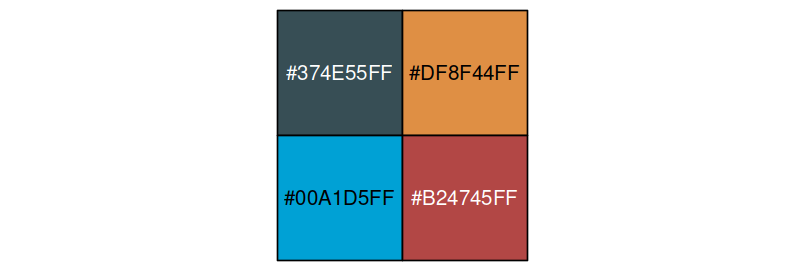

In [248]:
library(scales)
pal_jama_colors <- pal_jama("default")(4)
# Display colors
show_col(pal_jama_colors)

In [250]:
level_s

[1] "Proliferative"    "Immune-Modulated" "Immune-Inactive"

In [251]:
rr = c('Cluster 9','Cluster 11', 'Cluster 5',
       'Cluster 10', 'Cluster 1','Cluster 3',
       'Cluster 7','Cluster 6', 'Cluster 8',
       'Cluster 2', 'Cluster 4')

In [252]:
annotation_row <- data.frame(SpatioType = factor(xy_df$SpatioType, levels =level_s))
rownames(annotation_row) <- rownames(xy_df)  

In [253]:
grey_hex <- '#908D8B'

In [254]:

cluster_colors <- c(pal_jama_colors[c(1,3,4)])


In [255]:
annotation_colors <- list(`SpatioType` = setNames(cluster_colors,  level_s))


In [257]:
col_annotation <- HeatmapAnnotation(
  df = annotation_row,  # Use annotation_row for column annotations
  col = annotation_colors  # Use annotation_colors for colors
)

In [258]:
options(repr.plot.width= 6.7, repr.plot.height=2.25)

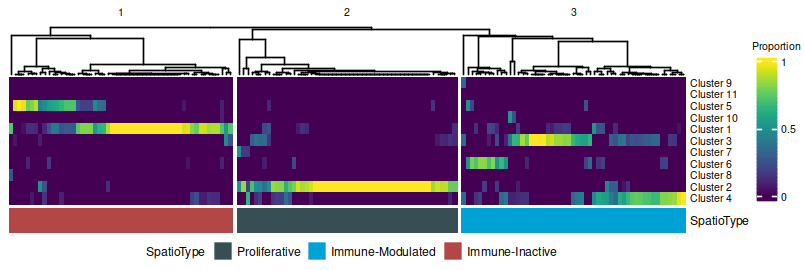

In [263]:
# Define the bottom annotation
col_annotation <- HeatmapAnnotation(
  df = annotation_row,  # Replace annotation_row with your annotation data
  col = annotation_colors,  # Annotation colors
  annotation_name_gp = gpar(fontsize = 7),  # Set the font size for annotation names
  annotation_legend_param = list(
    title = "SpatioType",  # Customize legend title
    title_position = "leftcenter",
    title_gp = gpar(fontsize = 7),  # Legend title font size
    labels_gp = gpar(fontsize = 7),  # Legend labels font size
    direction = "horizontal",  # Keep annotation legend horizontal at bottom
    nrow = 1  # Ensure the legend is in a single row
  )
)

# Define the heatmap
heatmap_plot <- Heatmap(
  t(xy_df[, rr]),  # Transpose the feature data
  cluster_rows = FALSE,  # No clustering for rows
  cluster_columns = as.dendrogram(linkage_matrix),  # Dendrogram for columns
  col = viridis(1000),  # Use viridis color scheme
  show_column_names = FALSE,  # Remove x-axis labels
  column_split = 3,  # Split columns into clusters with gaps
  bottom_annotation = col_annotation,  # Annotation at the bottom
  show_heatmap_legend = TRUE,  # Show heatmap legend
  row_title_gp = gpar(fontsize = 8),  # Row title font size
  column_title_gp = gpar(fontsize = 6),  # Column title font size
  row_names_gp = gpar(fontsize = 6),  # Row names font size
  column_names_gp = gpar(fontsize = 8),  # Column names font size
  use_raster = FALSE,  # Prevent scaling of fonts when resizing

  # Customize the heatmap legend to be vertical and on the right
  heatmap_legend_param = list(
    title = "Proportion",
    title_gp = gpar(fontsize = 6),
    labels_gp = gpar(fontsize = 6),
    direction = "vertical",  # Vertical legend on the right
    title_position = "topcenter",
    grid_height = unit(0.4, "cm"),
    grid_width = unit(0.4, "cm"),
    legend_height = unit(3, "cm")  # Adjust for better visual balance
  )
)


# Draw the heatmap with fixed font sizes and vertical legend on the right
pushViewport(viewport(width = unit(1, "npc"), height = unit(1, "npc")))
draw(heatmap_plot, heatmap_legend_side = "right", annotation_legend_side = "bottom")
upViewport()



In [25]:
# Save the heatmap to PNG with fixed font size
png("heatmap_plot.png", width = 6.7, height = 2.25, units = "in", res = 300)

# Draw the heatmap with fixed font sizes and vertical legend on the right
pushViewport(viewport(width = unit(1, "npc"), height = unit(1, "npc")))
draw(heatmap_plot, heatmap_legend_side = "right", annotation_legend_side = "bottom")
upViewport()

# Turn off the graphics device
dev.off()

pdf 
  2

## Survival validation (DFI)

Stratify the cohort by SpatioType and run Kaplan–Meier + log-rank. The published interpretation: SpatioType 3 (Immune-Inactive) has the worst DFI among the three groups.

In [ ]:
project <- "METABRIC"
meta <- pd$read_pickle("/vf/users/Ruppin_ST/Cell_revisions/super_meta.pkl")
meta <- meta[meta$cohort == project, ]

xy_df$slide_name <- rownames(xy_df)
meta$slide_name  <- rownames(meta)
xy_df <- merge(meta[, c("slide_name", "DFI", "DFI.time")], xy_df, by = "slide_name")
xy_df[["DFI.time"]] <- xy_df[["DFI.time"]] * 30
dim(xy_df)

In [266]:
surv_obj <- Surv(time = xy_df[[paste0(os_type, '.time')]], 
                 event = xy_df[[os_type]])

# Fit the Kaplan-Meier model
km_fit <- survfit(surv_obj ~ SpatioType, data = xy_df)

In [267]:

logrank_test <- survdiff(surv_obj ~ Metacluster, data = xy_df)

# Step 4: Extract p-value from the chi-square statistic
p_value <- 1 - pchisq(logrank_test$chisq, length(logrank_test$n) - 1)

# Print the p-value
print(paste("Log-rank test p-value:", p_value))


[1] "Log-rank test p-value: 0.217574987755436"


In [269]:
# Subset data for clusters 1 and 3
xy_df_1_3 <- xy_df %>%
  filter(SpatioType %in% c("Immune-Inactive", "Immune-Modulated"))

# Create the survival object
surv_obj_1_3 <- Surv(time = xy_df_1_3[[paste0(os_type, '.time')]], 
                     event = xy_df_1_3[[os_type]])

# Perform the log-rank test for clusters 1 and 3
survdiff_1_3 <- survdiff(surv_obj_1_3 ~ SpatioType, data = xy_df_1_3)

In [270]:
# Repeat for clusters 2 and 3
xy_df_2_3 <- xy_df %>%
  filter(SpatioType %in% c("Immune-Inactive", "Immune-Modulated"))

surv_obj_2_3 <- Surv(time = xy_df_2_3[[paste0(os_type, '.time')]], 
                     event = xy_df_2_3[[os_type]])

survdiff_2_3 <- survdiff(surv_obj_2_3 ~ SpatioType, data = xy_df_2_3)

# Extract p-values for cluster comparisons
pval_3_1 <- survdiff_1_3$pvalue  # P-value between cluster 3 and 1
pval_3_2 <- survdiff_2_3$pvalue  # P-value between cluster 3 and 2

In [271]:
# Clusters 2 and 3 comparison
xy_df_2_3 <- xy_df %>%
  filter(SpatioType %in% c("Immune-Inactive", "Immune-Modulated"))
surv_obj_2_3 <- Surv(time = xy_df_2_3[[paste0(os_type, '.time')]], 
                     event = xy_df_2_3[[os_type]])
survdiff_2_3 <- survdiff(surv_obj_2_3 ~ Metacluster, data = xy_df_2_3)

# Calculate hazard ratios
hr_1 <- -survdiff_1_3$obs[2]/survdiff_1_3$exp[2]  # For clusters 1 vs 3
hr_2 <- -survdiff_2_3$obs[2]/survdiff_2_3$exp[2]  # For clusters 2 vs 3

# Convert to one-sided p-values if cluster 3 has worse survival
# Convert to one-sided p-values if clusters 1 and 2 have worse survival than 3
pval_3_1 <- survdiff_1_3$pvalue/2 * (hr_1 < 1) + (1 - survdiff_1_3$pvalue/2) * (hr_1 > 1)
pval_3_2 <- survdiff_2_3$pvalue/2 * (hr_2 < 1) + (1 - survdiff_2_3$pvalue/2) * (hr_2 > 1)

In [272]:
pval_3_1

[1] 0.270751

In [273]:
pval_3_2

[1] 0.270751

In [160]:
# Step 2: Plot the Kaplan-Meier curve with the ggsurvplot function
p <- ggsurvplot(
  km_fit, 
  data = xy_df, 
  #censor.shape = 3,  # Change censor marker shape
  censor.size = 4,#1.5,  # Reduce censor marker size
  # Change legends: title & labels
  legend.title = "SpatioType",
  legend.labs = legend.labs,
  # Add p-value and intervals
  conf.int = FALSE,
  legend = 'none',  # We'll move the legend manually into the plot
  risk.table = FALSE,
  tables.height = 0.2,
  tables.theme = theme_cleantable(),
  #xlim = c(0, 279),
  palette = cluster_colors,
  xlab = "Time (Months)",  
  ylab = "Disease-free survival probability",
  font.x = 6,  
  font.y = 6,  
  font.tickslab = 5,  
  font.legend = 6,  
  font.title = 8,
  title = 'All breast cancer patients',
  size = 1,
  ggtheme = theme_classic()
)


p$plot <- p$plot +
  theme(
    # Legend key (symbol area) with white background
    legend.key = element_rect(
      fill = "white",
      colour = "transparent"  # No border
    ),
    
    legend.text = element_text(
      lineheight = 1.1  # Space between legend lines
    ),
    # White background around the entire legend (text + symbols)
    legend.background = element_rect(
      fill = "white",
      colour = "white"  # Optional: black or gray for subtle border
    ),
    
    # Reduce space around the legend box
    legend.margin = margin(t = 2, r = 2, b = 2, l = 2, unit = "pt"),
    
    # Adjust legend position and size
    legend.position = c(0.5, 0.26),
    legend.key.size = unit(1.3, "lines"),
    legend.spacing.y = unit(2, "lines"),
    
    # Legend title margin adjustment
    legend.title = element_text(margin = margin(b = 2, unit = "pt")),
    
    # Center plot title
    plot.title = element_text(hjust = 0.5, margin = margin(b = 2, unit = "pt"))
  ) +
  guides(
    color = guide_legend(
      override.aes = list(size = 4, colour = cluster_colors)  # Thicker lines in legend
    )
  )  



# Step 3: Add manual annotations for the pairwise p-values
p$plot <- p$plot + 
  annotate("text", x = 255, y = 0.685, label = paste0("p = ", format(pval_3_1, digits = 1)), size = 2) +
  # Adding the vertical line
  annotate("segment", x = 200, xend = 200, y = 0.61, yend = 0.76, color = "black", linewidth = 0.15) +
  # Adding the bottom horizontal line
  annotate("segment", x = 198, xend = 202, y = 0.61, yend = 0.61, color = "black", linewidth = 0.15) +
  # Adding the top horizontal line
  annotate("segment", x = 198, xend = 202, y = 0.76, yend = 0.76, color = "black", linewidth = 0.15)

# Display the plot



ERROR: Error: object 'legend.labs' not found
